Saving iris (1).csv to iris (1).csv


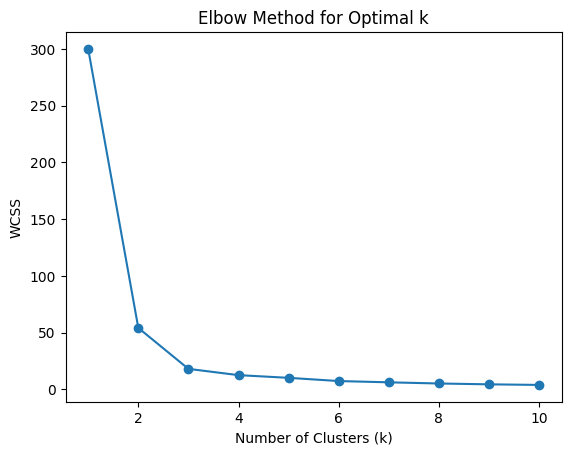

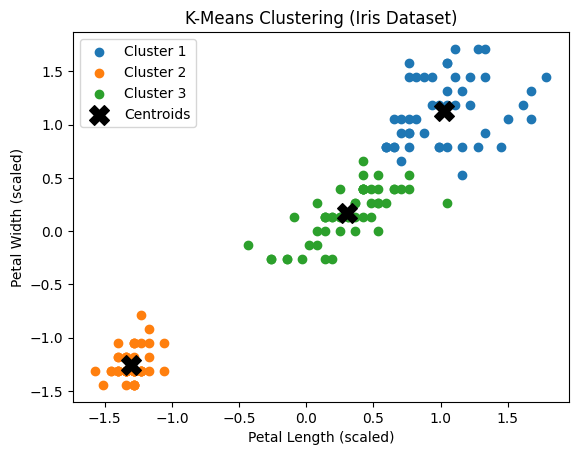

In [4]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv("iris (1).csv")

# Use only required features
X = df[['petal_length', 'petal_width']]

# -----------------------------
# 2. Preprocessing (IMPORTANT)
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# 3. Elbow Method
# -----------------------------
wcss = []  # Within Cluster Sum of Squares

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.show()

# -----------------------------
# 4. Apply KMeans with optimal k
# -----------------------------
# From elbow graph, usually k = 3 for iris
kmeans = KMeans(n_clusters=3, random_state=42)
y_pred = kmeans.fit_predict(X_scaled)

# -----------------------------
# 5. Visualization of Clusters
# -----------------------------
plt.scatter(X_scaled[y_pred == 0, 0], X_scaled[y_pred == 0, 1], label='Cluster 1')
plt.scatter(X_scaled[y_pred == 1, 0], X_scaled[y_pred == 1, 1], label='Cluster 2')
plt.scatter(X_scaled[y_pred == 2, 0], X_scaled[y_pred == 2, 1], label='Cluster 3')

# Plot centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='black', marker='X', label='Centroids')

plt.xlabel('Petal Length (scaled)')
plt.ylabel('Petal Width (scaled)')
plt.title('K-Means Clustering (Iris Dataset)')
plt.legend()
plt.show()